# Laminate optimization 

## 01 - Introduction

Let's take a look at laminates in a two-dimensional domain, i.e. the strain is given by
$$ 
\bm{\varepsilon}
= 
\begin{pmatrix}
    \varepsilon_{xx}\\
    \varepsilon_{yy}\\
    2\varepsilon_{xy}
\end{pmatrix}
$$

and the stress is given by 

$$ 
\bm{\sigma}
= 
\begin{pmatrix}
    \sigma_{xx}\\
    \sigma_{yy}\\
    \sigma_{xy}
\end{pmatrix}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

In the reduced stiffness notation, the roation matrix is given as 

$$
\bm{R} (\phi)
=
\begin{pmatrix}
    \cos^2{\phi} & \sin^2{\phi} & 2\sin{\phi}\cos{\phi}\\
    \sin^2{\phi} & \cos^2{\phi} & -2\sin{\phi}\cos{\phi}\\
    -\sin{\phi}\cos{\phi} & \sin{\phi}\cos{\phi} & \cos^2{\phi}-\sin^2{\phi}
\end{pmatrix}
$$

Note that this matrix is not symmetrical due to the convention of writing $\gamma_{xy}=2\varepsilon_{xy}$ for the shear stress. This is rooted in the defintion of the shear modulus $\sigma_{xy}=G\gamma_{xy}$.

In [2]:
def R(phi):
    """Rotation tensor for angle phi"""
    return np.array(
        [
            [np.cos(phi) ** 2, np.sin(phi) ** 2, 2 * np.sin(phi) * np.cos(phi)],
            [np.sin(phi) ** 2, np.cos(phi) ** 2, -2 * np.sin(phi) * np.cos(phi)],
            [
                -np.sin(phi) * np.cos(phi),
                np.sin(phi) * np.cos(phi),
                np.cos(phi) ** 2 - np.sin(phi) ** 2,
            ],
        ]
    )

A single 2D ply compliance tensor is given as 


$$
\begin{pmatrix}
    \varepsilon_{xx}\\
    \varepsilon_{yy}\\
    2\varepsilon_{xy}
\end{pmatrix}
=
\begin{pmatrix}
    \frac{1}{E_{xx}} & -\frac{\nu_{xy}}{E_{xx}} & 0\\
    -\frac{\nu_{yx}}{E_{yy}} & \frac{1}{E_{yy}} & 0\\
    0 & 0 & \frac{1}{G_{xy}}
\end{pmatrix}
\begin{pmatrix}
    \sigma_{xx}\\
    \sigma_{yy}\\
    \sigma_{xy}
\end{pmatrix}
$$
or as stiffness tensor 
$$
\begin{pmatrix}
    \sigma_{xx}\\
    \sigma_{yy}\\
    \sigma_{xy}
\end{pmatrix}
=
\begin{pmatrix}
    \frac{E_{xx}}{1-\nu_{xy}\nu_{yx}} & \frac{\nu_{xy}E_{yy}}{1-\nu_{xy}\nu_{yx}} & 0\\
    \frac{\nu_{yx}E_{xx}}{1-\nu_{xy}\nu_{yx}}& \frac{E_{yy}}{1-\nu_{xy}\nu_{yx}} & 0\\
    0 & 0 & G_{xy}
\end{pmatrix}
\begin{pmatrix}
    \varepsilon_{xx}\\
    \varepsilon_{yy}\\
    2\varepsilon_{xy}
\end{pmatrix}
$$

The stiffness is characterized by four properties $E_{xx}, E_{yy}, G_{xy}, \nu_{xy}$. The tensor is symmetric with 
$$ \frac{\nu_{xy}}{E_{xx}}=\frac{\nu_{yx}}{E_{yy}} $$

In [3]:
def C(E_xx, E_yy, G_xy, nu_xy):
    """Stiffness tensor"""
    nu_yx = E_yy / E_xx * nu_xy
    return np.array(
        [
            [E_xx / (1 - nu_xy * nu_yx), nu_xy * E_yy / (1 - nu_xy * nu_yx), 0],
            [nu_yx * E_xx / (1 - nu_xy * nu_yx), E_yy / (1 - nu_xy * nu_yx), 0],
            [0, 0, G_xy],
        ]
    )


def S(E_xx, E_yy, G_xy, nu_xy):
    """Compliance tensor"""
    nu_yx = E_yy / E_xx * nu_xy
    return np.array(
        [[1 / E_xx, -nu_xy / E_xx, 0], [-nu_yx / E_yy, 1 / E_yy, 0], [0, 0, 1 / G_xy]]
    )

Let's assume the single uni-directional ply is subjected to uni-axial loading 
$$
\bm{\sigma}
= 
\begin{pmatrix}
    \sigma_{xx}\\
    0\\
    0
\end{pmatrix}
$$
and the material orientation is described by an angle $\phi$ between the load axis an the uni-directional fiber direction. 

For this case, the compliance matrix in the loading coordinate system is obtained by rotating the compliance matrix to this system using the rotation tensor $R$ according to 
$$\bm{S}_{rot} = \bm{R}(\phi)^\top \bm{S} \bm{R}(\phi).$$

The measured Young's modulus in load direction is then simply $\frac{1}{S_{11}}$, the shear modulus is $\frac{1}{S_{33}}$ and the poisson ratio is $-\frac{S_{12}}{S_{22}}$. Their values over a range $\phi \in [0, 2\pi]$ is shown in the following plots.
For isotropic conditions ($E_{xx}=E{yy}=E$, $G=\frac{E}{2(1+\nu)}$), these graphs should all be circles. 
Inverting the stiffness tensor (orange dashed lines) should always result in the same curves as the compliance matrix (solid blue lines).

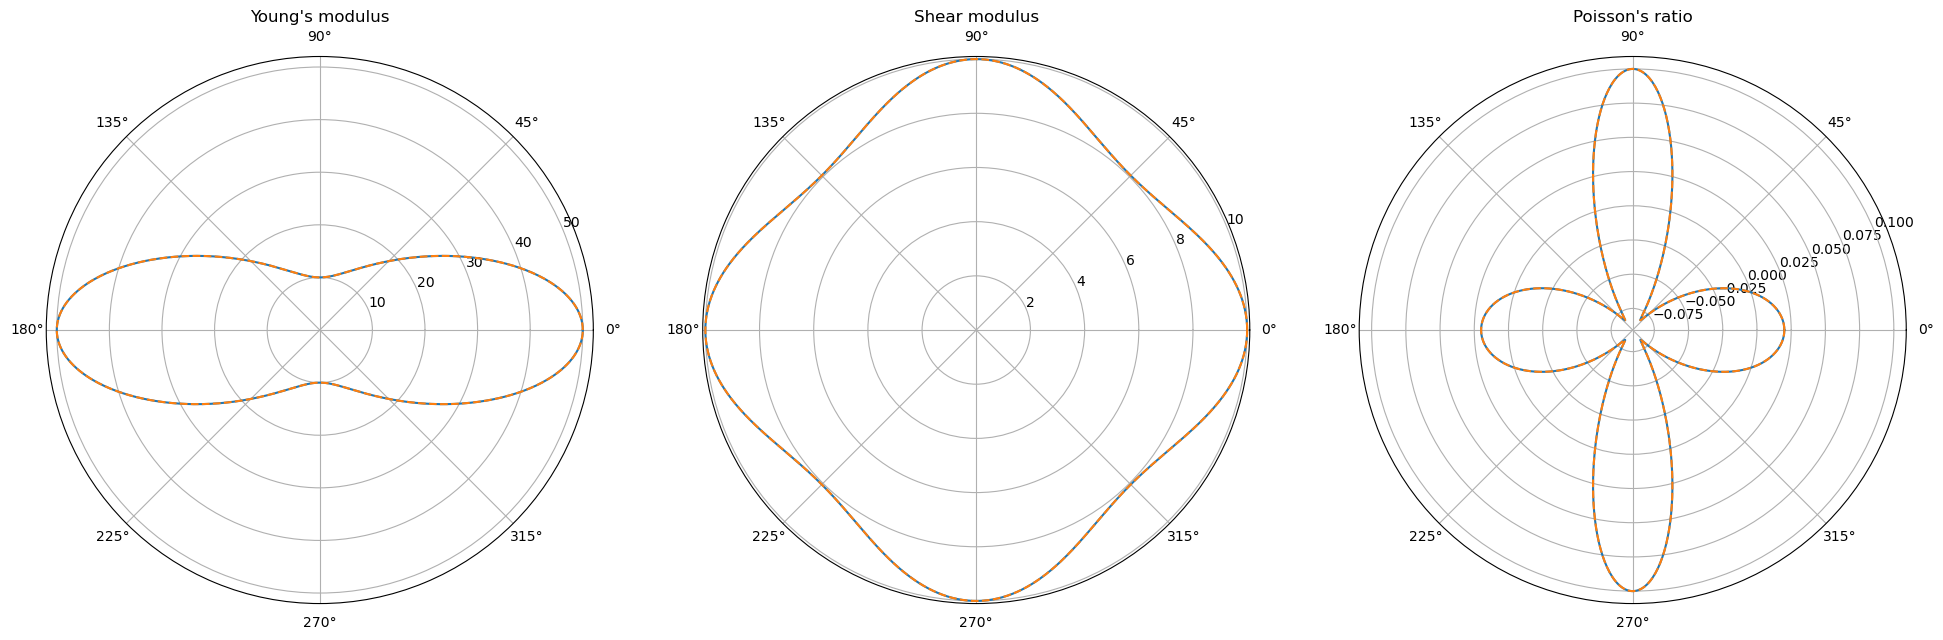

In [4]:
# compute the compliance matrices
N = 1000
phi = np.linspace(0, 2 * np.pi, N)
Srot = np.einsum("ji...,jk,kl...->il...", R(phi), S(50, 10, 10, 0.1), R(phi))
Crot = np.einsum("ij...,jk,lk...->il...", R(phi), C(50, 10, 10, 0.1), R(phi))
Cinv = np.linalg.inv(np.moveaxis(Crot, -1, 0))

# plot the results
fig, ax = plt.subplots(
    nrows=1, ncols=3, subplot_kw={"projection": "polar"}, figsize=(24, 8)
)
ax[0].plot(phi, 1 / Srot[0, 0, :])
ax[0].plot(phi, 1 / Cinv[:, 0, 0], "--")
ax[0].set_title("Young's modulus")
ax[1].plot(phi, 1 / Srot[2, 2, :])
ax[1].plot(phi, 1 / Cinv[:, 2, 2], "--")
ax[1].set_title("Shear modulus")
ax[2].plot(phi, -Srot[0, 1, :] / Srot[1, 1, :])
ax[2].plot(phi, -Cinv[:, 0, 1] / Cinv[:, 1, 1], "--")
ax[2].set_title("Poisson's ratio")
plt.show()

The stiffness of multiple plies is computed under the assumption that they experience identical strains (Voigt homogenization). With this approximation, the effective stiffness of $N$ plies with identical thickness and different rotations $\phi_i$ are
$$
\bm{C}_\textrm{eff} = \frac{1}{N} \sum_1^N \bm{R}(\phi_i) \bm{C} \bm{R}(\phi_i) ^\top
$$

The corresponding compliance tensor is then given by 
$$
\bm{S}_\textrm{eff} = \bm{C}_\textrm{eff}^{-1}
$$

## 02 - Inverse problem with C/C-SiC data from Shi et al.

Given observations of a laminate, we want to minimize the error between a computed stacked laminate of UD layers with $E_{xx}$, $E_{yy}$, $G_{xy}$, and $\nu_{xy}$ and the measured results to find the UD properties yielding the observed response. Therefore, we define a target function 

$$
L(P_j) = \sum_j^M \left(\frac{P_j - \tilde{P_j}}{\tilde{P_j}}\right)^2 
$$

where $P_j$ denotes a computed property from stacking the laminate and $\tilde{P_j}$ describes a measured observation.

![Table 2 from Shi et al. Paper](table_2_shi.png)

In [5]:
E090 = 72.8
G090 = 9.5
nu090 = 0.02
E45 = 25.4
G45 = 42.7
nu45 = 0.64


def target_function_shi(x):
    E_xx, E_yy, G_xy, nu_xy = x
    # Biax 0-90 Cross Ply Laminate
    C_090 = 0.5 * (
        np.einsum("ij,jk,lk->il", R(0), C(E_xx, E_yy, G_xy, nu_xy), R(0))
        + np.einsum(
            "ij,jk,lk->il", R(np.pi / 2), C(E_xx, E_yy, G_xy, nu_xy), R(np.pi / 2)
        )
    )
    S_090 = np.linalg.inv(C_090)
    # Biax 45-45 Cross Ply Laminate
    C_45 = 0.5 * (
        np.einsum(
            "ij,jk,lk->il", R(np.pi / 4), C(E_xx, E_yy, G_xy, nu_xy), R(np.pi / 4)
        )
        + np.einsum(
            "ij,jk,lk->il",
            R(np.pi / 4 + np.pi / 2),
            C(E_xx, E_yy, G_xy, nu_xy),
            R(np.pi / 4 + np.pi / 2),
        )
    )
    S_45 = np.linalg.inv(C_45)
    # Reference data for C/C-SiC from Shi et al. - 10.1111/ijac.13775
    loss = (
        ((1 / S_090[0, 0] - E090) / E090) ** 2
        + ((1 / S_45[0, 0] - E45) / E45) ** 2
        + ((1 / S_090[2, 2] - G090) / G090) ** 2
        + ((1 / S_45[2, 2] - G45) / G45) ** 2
        + ((-S_090[0, 1] / S_090[1, 1] - nu090) / nu090) ** 2
        + ((-S_45[0, 1] / S_45[1, 1] - nu45) / nu45) ** 2
    )
    return loss

We minimize the function $L(P_j)$ w.r.t. to all $P_j$. With a proper choice of test data, ist should give an unambiguous result for the UD ply properties. However, for the measurement performed by Shi et al. there is no unique solution for $E_{xx}$ and $E_{yy}$ because the 0° and 90° layers both contribute to the stiffness in a uniaxial tension test. Additional data with non-balanced ply configurations or off-axis data with other orientation than 45° is needed to resolve this.

In [6]:
bounds = [(1, 400), (1, 200), (1, 200), (-1, 1)]
result = differential_evolution(target_function_shi, bounds)
opt = result.x
print(f"E_xx: {opt[0]:.3f} GPa")
print(f"E_yy: {opt[1]:.3f} GPa")
print(f"G_xy: {opt[2]:.3f} GPa")
print(f"nu_xy: {opt[3]:.3f}")

E_xx: 135.105 GPa
E_yy: 20.192 GPa
G_xy: 8.530 GPa
nu_xy: 0.077


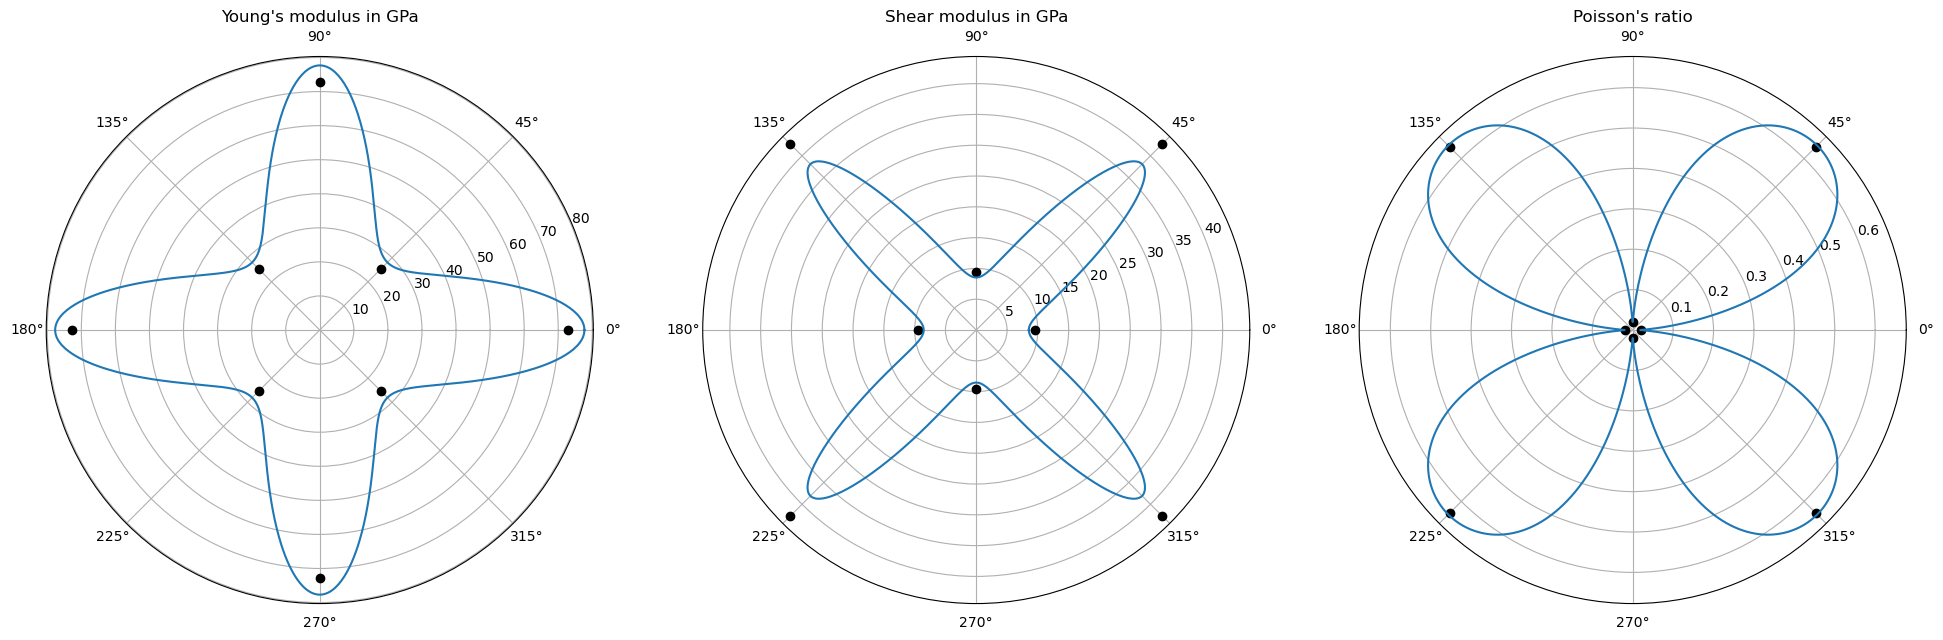

In [7]:
# compute the compliance matrices
N = 1000
phi = np.linspace(0, 2 * np.pi, N)
offset = np.pi / 2
C_eff = 0.5 * (
    np.einsum("ijZ,jk,lkZ->ilZ", R(phi), C(*opt), R(phi))
    + np.einsum("ijZ,jk,lkZ->ilZ", R(phi + offset), C(*opt), R(phi + offset))
)
Srot = np.linalg.inv(np.moveaxis(C_eff, -1, 0))

# plot young's modulus
fig, ax = plt.subplots(
    nrows=1, ncols=3, subplot_kw={"projection": "polar"}, figsize=(24, 8)
)
ax[0].plot(
    np.pi * np.array([0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75]),
    [E090, E45, E090, E45, E090, E45, E090, E45],
    "ok",
)
ax[0].plot(phi, 1 / Srot[:, 0, 0])
ax[0].set_title("Young's modulus in GPa")

# plot shear modulus
ax[1].plot(
    np.pi * np.array([0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75]),
    [G090, G45, G090, G45, G090, G45, G090, G45],
    "ok",
)
ax[1].plot(phi, 1 / Srot[:, 2, 2])
ax[1].set_title("Shear modulus in GPa")

# plot poisson ratio
ax[2].plot(
    np.pi * np.array([0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75]),
    [nu090, nu45, nu090, nu45, nu090, nu45, nu090, nu45],
    "ok",
)
ax[2].plot(phi, -Srot[:, 0, 1] / Srot[:, 1, 1])
ax[2].set_title("Poisson's ratio")
plt.show()

## 03 - Inverse problem with C/C-SiC data from Jonas and Florina

In [8]:
# Biaxial 0-90 Cross Ply Laminate [0,90,0,90,0,90,90,0,90,0,90,0]
E090 = 67.687
G090 = 8.925
# Biaxial 0-0-90 Cross Ply Laminate [0,0,90,0,0,90,90,0,0,90,0,0]
E0090 = 80.0  # TODO: This is just a dummy value !!!
# # Biaxial 0-90-90 Cross Ply Laminate [0,90,90,0,90,90,90,90,0,90,90,0]
# E09090 = ...


def target_function_jonas(x):
    E_xx, E_yy, G_xy, nu_xy = x
    # 0-90 laminate
    C_090 = 0.5 * np.einsum(
        "ij,jk,lk->il", R(0), C(E_xx, E_yy, G_xy, nu_xy), R(0)
    ) + 0.5 * np.einsum(
        "ij,jk,lk->il", R(np.pi / 2), C(E_xx, E_yy, G_xy, nu_xy), R(np.pi / 2)
    )
    S_090 = np.linalg.inv(C_090)
    # 0-0-90 laminate
    C_0090 = 8.0 / 12.0 * np.einsum(
        "ij,jk,lk->il", R(0), C(E_xx, E_yy, G_xy, nu_xy), R(0)
    ) + 4.0 / 12.0 * np.einsum(
        "ij,jk,lk->il", R(np.pi / 2), C(E_xx, E_yy, G_xy, nu_xy), R(np.pi / 2)
    )
    S_0090 = np.linalg.inv(C_0090)
    C_45 = 0.5 * (
        np.einsum(
            "ij,jk,lk->il", R(np.pi / 4), C(E_xx, E_yy, G_xy, nu_xy), R(np.pi / 4)
        )
        + np.einsum(
            "ij,jk,lk->il",
            R(np.pi / 4 + np.pi / 2),
            C(E_xx, E_yy, G_xy, nu_xy),
            R(np.pi / 4 + np.pi / 2),
        )
    )
    S_45 = np.linalg.inv(C_45)
    # Reference data for C/C-SiC from Jonas
    loss = np.sqrt(
        (
            ((1 / S_090[0, 0] - E090) / E090) ** 2
            + ((1 / S_090[2, 2] - G090) / G090) ** 2
            + ((1 / S_0090[0, 0] - E0090) / E0090) ** 2
            + ((-S_090[0, 1] / S_090[1, 1] - nu090) / nu090) ** 2
            + ((-S_45[0, 1] / S_45[1, 1] - nu45) / nu45) ** 2
        )
        / 5
    )
    return loss

Final error: 2.9 %
E_xx: 101.185 GPa
E_yy: 37.597 GPa
G_xy: 8.685 GPa
nu_xy: 0.037


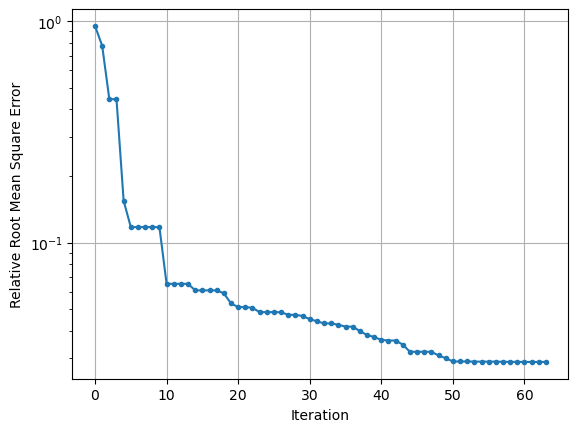

In [9]:
history = []


# Callback to track history
def cb(intermediate_result):
    history.append(intermediate_result.fun)


# Optimization
bounds = [(1, 400), (1, 200), (1, 200), (-1, 1)]
result = differential_evolution(target_function_jonas, bounds, callback=cb)

# Optimization history
plt.semilogy(history, ".-")
plt.xlabel("Iteration")
plt.ylabel("Relative Root Mean Square Error")
plt.grid()

# Results
opt = result.x
print(f"Final error: {100*result.fun:.1f} %")
print(f"E_xx: {opt[0]:.3f} GPa")
print(f"E_yy: {opt[1]:.3f} GPa")
print(f"G_xy: {opt[2]:.3f} GPa")
print(f"nu_xy: {opt[3]:.3f}")

## Visualization of data fit 

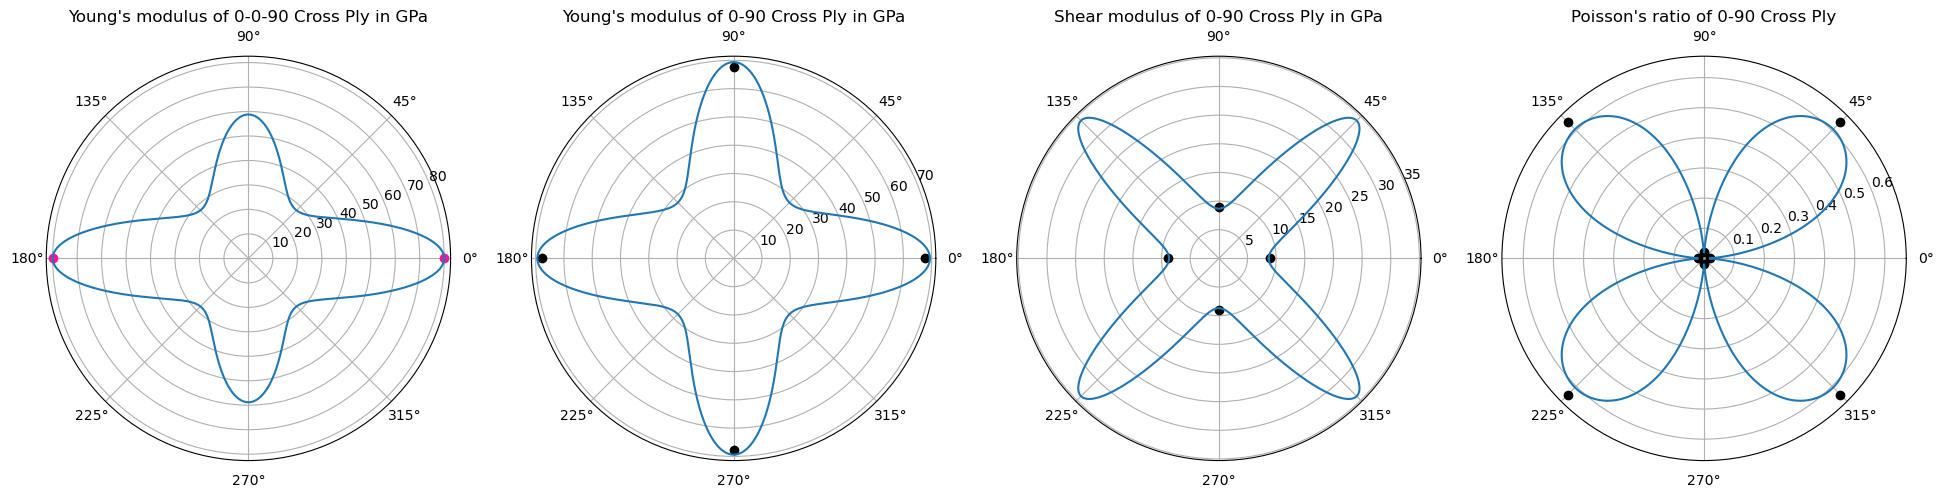

In [10]:
# compute the compliance matrices
N = 1000
phi = np.linspace(0, 2 * np.pi, N)
offset = np.pi / 2

# 0-90 Cross Ply Laminate
C_eff_0_90 = 0.5 * np.einsum(
    "ijZ,jk,lkZ->ilZ", R(phi), C(*opt), R(phi)
) + 0.5 * np.einsum("ijZ,jk,lkZ->ilZ", R(phi + offset), C(*opt), R(phi + offset))
Srot_0_90 = np.linalg.inv(np.moveaxis(C_eff_0_90, -1, 0))

# 0-0-90 Cross Ply Laminate
C_eff_0_0_90 = 8.0 / 12.0 * np.einsum(
    "ijZ,jk,lkZ->ilZ", R(phi), C(*opt), R(phi)
) + 4.0 / 12.0 * np.einsum("ijZ,jk,lkZ->ilZ", R(phi + offset), C(*opt), R(phi + offset))
Srot_0_0_90 = np.linalg.inv(np.moveaxis(C_eff_0_0_90, -1, 0))

# Plots
fig, ax = plt.subplots(
    nrows=1, ncols=4, subplot_kw={"projection": "polar"}, figsize=(24, 8)
)

# 0-0-90 Cross Ply Laminate Youngs Modulus
ax[0].plot([0, np.pi], [80, 80], "o", color="deeppink")
ax[0].plot(phi, 1 / Srot_0_0_90[:, 0, 0])
ax[0].set_title("Young's modulus of 0-0-90 Cross Ply in GPa")

# 0-90 Cross Ply Laminate Youngs Modulus
ax[1].plot(
    [0, 0.5 * np.pi, np.pi, 1.5 * np.pi],
    [67.687, 67.687, 67.687, 67.687],
    "ok",
)
ax[1].plot(phi, 1 / Srot_0_90[:, 0, 0])
ax[1].set_title("Young's modulus of 0-90 Cross Ply in GPa")

# 0-90 Cross Ply Laminate Shear Modulus
ax[2].plot(
    [0, 0.5 * np.pi, np.pi, 1.5 * np.pi],
    [8.925, 8.925, 8.925, 8.925],
    "ok",
)
ax[2].plot(phi, 1 / Srot_0_90[:, 2, 2])
ax[2].set_title("Shear modulus of 0-90 Cross Ply in GPa")

# plot poisson ratio
ax[3].plot(
    np.pi * np.array([0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75]),
    [nu090, nu45, nu090, nu45, nu090, nu45, nu090, nu45],
    "ok",
)
ax[3].plot(phi, -Srot_0_90[:, 0, 1] / Srot_0_90[:, 1, 1])
ax[3].set_title("Poisson's ratio of 0-90 Cross Ply")
plt.show()

Using the optimization result, we may plot the UD layer properties.

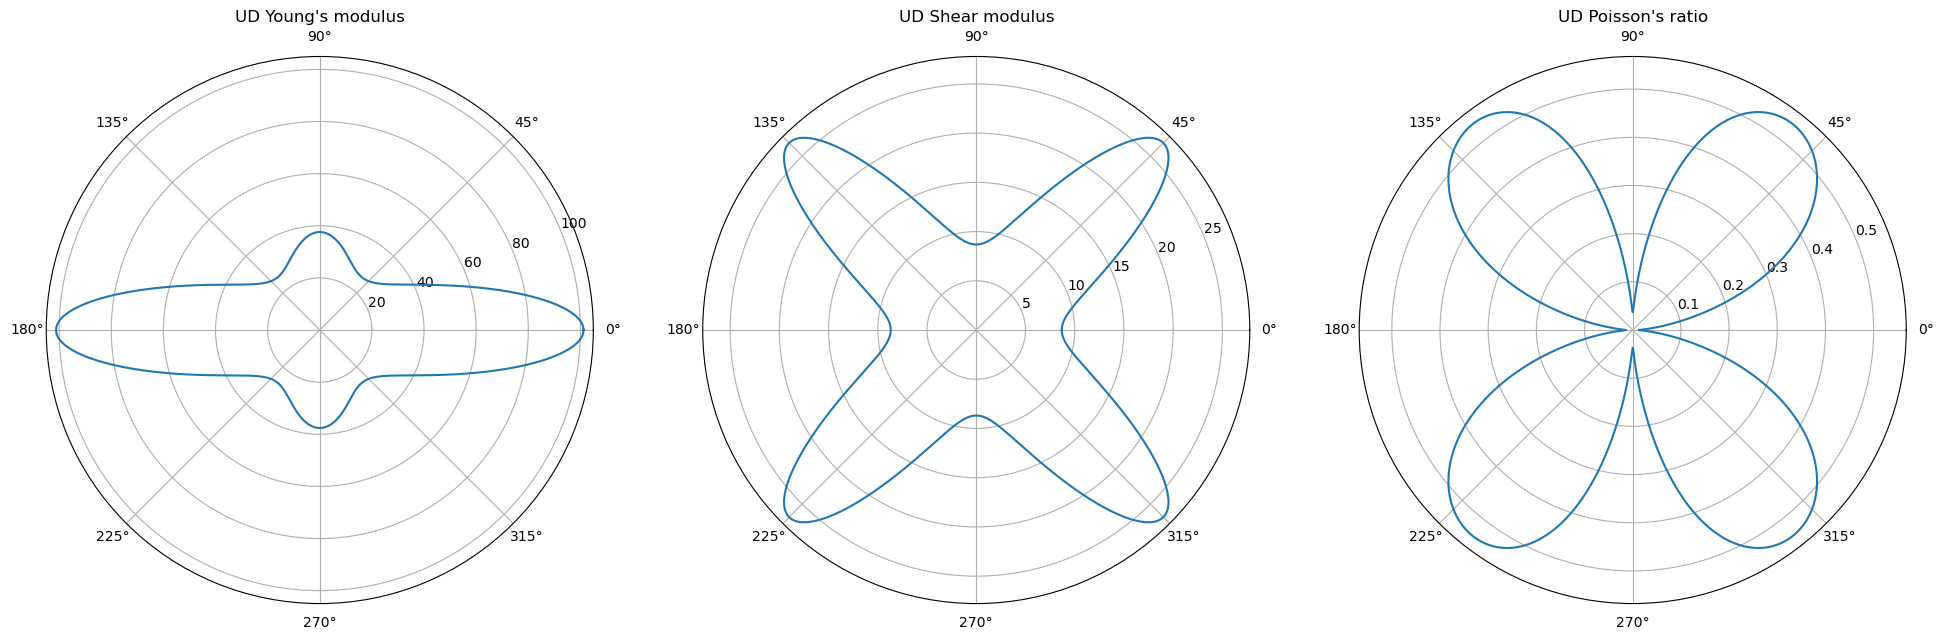

In [11]:
# compute the compliance matrices
N = 1000
phi = np.linspace(0, 2 * np.pi, N)
Srot = np.einsum("ji...,jk,kl...->il...", R(phi), S(*opt), R(phi))

# plot the results
fig, ax = plt.subplots(
    nrows=1, ncols=3, subplot_kw={"projection": "polar"}, figsize=(24, 8)
)
ax[0].plot(phi, 1 / Srot[0, 0, :])
ax[0].set_title("UD Young's modulus")
ax[1].plot(phi, 1 / Srot[2, 2, :])
ax[1].set_title("UD Shear modulus")
ax[2].plot(phi, -Srot[0, 1, :] / Srot[1, 1, :])
ax[2].set_title("UD Poisson's ratio")
plt.show()